In [1]:
import torch
from torch import nn
from d2l import torch as d2l

#### 3.7.2 High-Dimensional Linear Regression

In [2]:
class Data(d2l.DataModule):
    def __init__(self, num_train, num_val, num_inputs, batch_size):
        self.save_hyperparameters()
        n = num_train + num_val
        self.X = torch.randn(n, num_inputs)
        noise = torch.randn(n, 1) * 0.01
        w, b = torch.ones((num_inputs, 1)) * 0.01, 0.05
        self.y = torch.matmul(self.X, w) + b + noise

    def get_dataloader(self, train):
        i = slice(0, self.num_train) if train else slice(self.num_train, None)
        return self.get_tensorloader([self.X, self.y], train, i)

#### 3.7.3 Implementation form Scratch

In [3]:
def l2_penalty(w):
    return (w ** 2).sum() / 2

##### 3.7.3.2 Defining the Model

In [4]:
class WeightDecayScratch(d2l.LinearRegressionScratch):
    def __init__(self, num_inputs, lambd, lr, sigma=0.01):
        super().__init__(num_inputs, lr, sigma)
        self.save_hyperparameters()

    def loss(self, y_hat, y):
        return (super().loss(y_hat, y) + self.lambd * l2_penalty(self.w))

In [5]:
data = Data(num_train=20, num_val=100, num_inputs=200, batch_size=5)
trainer = d2l.Trainer(max_epochs=10)

def train_scratch(lambd):
    model = WeightDecayScratch(num_inputs=200, lambd=lambd, lr=0.01)
    model.board.yscale='log'
    trainer.fit(model, data)
    print('L2 norm of w:', float(l2_penalty(model.w)))

##### 3.7.3.3 Training without Regularization

L2 norm of w: 0.010624212212860584


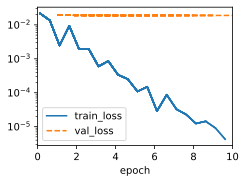

In [6]:
train_scratch(0)

##### 3.7.3.4 Using Weight Decay

L2 norm of w: 0.0017866112757474184


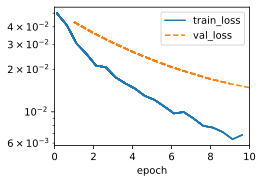

In [7]:
train_scratch(3)

#### 3.7.4 Concise Implementation

In [9]:
class WeightDecay(d2l.LinearRegression):
    def __init__(self, wd, lr):
        super().__init__(lr)
        self.save_hyperparameters()
        self.wd = wd

    def configure_optimizers(self):
        return torch.optim.SGD([{'params': self.net.weight, 'weight_decay': self.wd}, 
                                {'params': self.net.bias}], lr=self.lr)

L2 norm of w: 0.01453005988150835


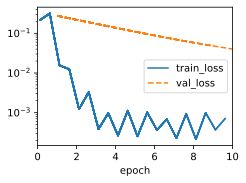

In [10]:
model = WeightDecay(wd=3, lr=0.01)
model.board.yscale='log'
trainer.fit(model, data)

print('L2 norm of w:', float(l2_penalty(model.get_w_b()[0])))

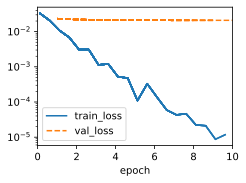

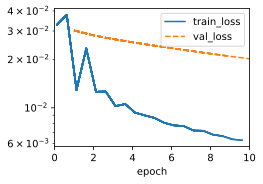

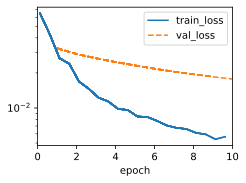

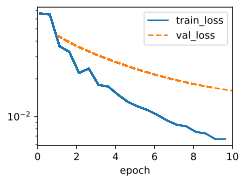

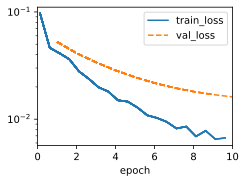

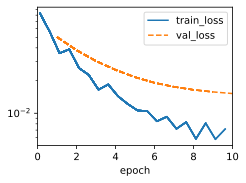

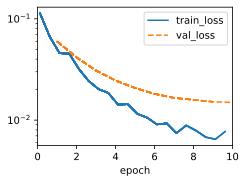

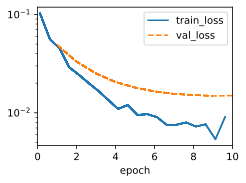

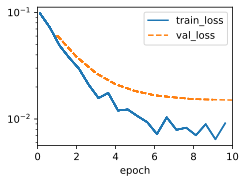

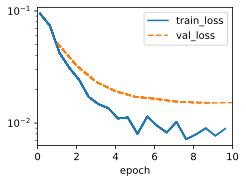

In [50]:
# exercise_1
class MyWeightDecayScratch(WeightDecayScratch):
    def __init__(self, num_inputs, lambd, lr, sigma=0.01):
        super().__init__(num_inputs, lr, sigma)
        self.save_hyperparameters()
        self.train_losses = []  # 存储训练损失
        self.val_losses = []    # 存储验证损失

    def record_loss(self, loss, is_train):
        if is_train:
            self.train_losses.append(loss.item())
        else:
            self.val_losses.append(loss.item())

# 修改 Trainer 类，使其在训练和验证阶段记录损失
class MyTrainer(d2l.Trainer):
    def __init__(self, max_epochs):
        super().__init__(max_epochs)
        self.save_hyperparameters()
        self.max_epochs = max_epochs

    def fit(self, model, data):
        train_dataloader = data.get_dataloader(train=True)
        val_dataloader = data.get_dataloader(train=False)
        # 使用 PyTorch 内置的 SGD 优化器
        optimizer = torch.optim.SGD(model.parameters(), lr=model.lr)
        for epoch in range(self.max_epochs):
            # 训练阶段
            model.train()
            for batch in train_dataloader:
                loss = model.training_step(batch)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                model.record_loss(loss, is_train=True)

            # 验证阶段
            model.eval()
            with torch.no_grad():
                for batch in val_dataloader:
                    loss = model.validation_step(batch)
                    model.record_loss(loss, is_train=False)

def my_train_scratch(trainer, data, lambd):
    model = MyWeightDecayScratch(num_inputs=200, lambd=lambd, lr=0.01)
    model.board.yscale='log'
    trainer.fit(model, data)
    return model.train_losses, model.val_losses

data = Data(num_train=20, num_val=100, num_inputs=200, batch_size=5)
trainer = d2l.Trainer(max_epochs=10)
lambd = torch.arange(0, 10, 1)
train_losses = []
val_losses = []

for l in lambd:
    train_loss, val_loss = my_train_scratch(trainer, data, lambd=l.item())
    train_losses.append(train_loss)
    val_losses.append(val_loss)

##### exercise_2
May not be thr optimal value.  
Cause under the selected value, both training and validation value could not be the minimum.  
But we still choose this certain value for that it is functional in restraining the complexity and the stability.  
Which costs not much also.

##### exercise_4
* $||A||^2_F = tr(A^TA) = tr(AA^T)$&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;tr(A)为矩阵的迹，为矩阵主对角线元素之和
* 谱范数$||A||^2_2 = \sigma_{max}(A) = \lambda_{max}(A^TA)$&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;$\lambda_{max}(A)$为矩阵最大特征值

##### exercise_5
We may eager to find out the w to make the posterior P(w|X,y) reaches its maximum,  
which is called Maximun A Posterior Estimation (MAP).    